# Phase 2 · Task 9 — VIX × Alignment × Direction Stratification

**Question:** Task 8 showed NS · EOD at 0.75×ATR is positive EV (+347 pts/yr)
but has a **−338 pt worst trade**. Can we find a sub-population of events
where worst-case is bounded and EV stays positive?

**Method.** At the 0.75×ATR threshold, tag every event with:
- **VIX regime** at prev close: low (<15), mid (15–25), high (>25)
- **Trend alignment**: concurrent (gap matches 30-day trend) / incongruent (against it)
- **Direction**: gap_up / gap_down

Then stratify NS · EOD pnl across all 1D, 2D and 3D combinations. The goal is
a cell with EV>0, worst > −150 pts, and ≥ 20 events/yr.


## 1 · Setup & data

In [1]:
import datetime, os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm as N

SYMBOLS    = ['ES', 'NQ', 'RTY', 'YM']
PATHS      = {s: f'data/{s}_1m_2019_2026.csv' for s in SYMBOLS}
THRESHOLD  = 0.75
YEARS      = 7
WIDTH_ATR  = 0.5
T_FULL     = 1 / 252
TREND_LOOKBACK = 30
VIX_REGIMES = {'low': (0, 15), 'mid': (15, 25), 'high': (25, 999)}

plt.style.use('dark_background')
os.makedirs('charts', exist_ok=True)

def load_daily(path):
    df = pd.read_csv(path, parse_dates=['ts_event']).set_index('ts_event')
    df.index = pd.to_datetime(df.index, utc=True).tz_convert('America/New_York')
    t = df.index.time
    sess = df[(t >= datetime.time(9, 30)) & (t <= datetime.time(16, 0))]
    daily = sess.resample('1D').agg(
        open=('open', 'first'), high=('high', 'max'),
        low=('low', 'min'), close=('close', 'last'), volume=('volume', 'sum'),
    ).dropna()
    return daily[daily['volume'] > 0]

daily_all = {s: load_daily(PATHS[s]) for s in SYMBOLS}
vix = pd.read_csv('data/VIX_daily_2019_2026.csv', index_col=0, parse_dates=True)
vix.index = pd.to_datetime(vix.index)
vix_series = vix['close']
print('Data loaded.')


Data loaded.


## 2 · Build event table

`detect_gaps_with_alignment()` tags each event with `direction`, `trend_30d`,
`alignment`, and `vix_regime`. The credit and EOD pnl are computed with
Black-Scholes at S=open, T=1/252.


In [2]:
def detect_gaps_with_alignment(daily, symbol, threshold, lookback):
    d = daily.copy()
    pc = d['close'].shift(1)
    tr = pd.concat([(d['high'] - d['low']),
                    (d['high'] - pc).abs(),
                    (d['low'] - pc).abs()], axis=1).max(axis=1)
    d['atr']        = tr.ewm(span=14, adjust=False).mean()
    d['prev_close'] = pc
    d['gap_ratio']  = (d['open'] - pc) / d['atr']
    d['direction']  = np.where(d['gap_ratio'] >=  threshold, 'gap_up',
                      np.where(d['gap_ratio'] <= -threshold, 'gap_down', 'none'))
    d['close_Nd']   = d['close'].shift(lookback)
    d['trend_30d']  = np.where(d['close'] > d['close_Nd'], 'bullish', 'bearish')
    d['alignment']  = np.where(
        ((d['direction'] == 'gap_up')   & (d['trend_30d'] == 'bullish')) |
        ((d['direction'] == 'gap_down') & (d['trend_30d'] == 'bearish')),
        'concurrent',
        np.where(
            ((d['direction'] == 'gap_up')   & (d['trend_30d'] == 'bearish')) |
            ((d['direction'] == 'gap_down') & (d['trend_30d'] == 'bullish')),
            'incongruent', 'none'))
    ev = d[d['direction'] != 'none'].dropna(subset=['atr', 'prev_close', 'close_Nd']).copy()
    ev['symbol'] = symbol
    return ev

def bs_call(S, K, T, r, sigma):
    if T <= 1e-12 or sigma <= 0: return max(S - K, 0.0)
    d1 = (np.log(S / K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*N.cdf(d1) - K*np.exp(-r*T)*N.cdf(d2)
def bs_put(S, K, T, r, sigma):
    return bs_call(S, K, T, r, sigma) - S + K*np.exp(-r*T)

def spread_value(S, K_short, K_long, direction, T, sigma, r=0.05):
    if direction == 'gap_up':
        return bs_put(S, K_short, T, r, sigma) - bs_put(S, K_long, T, r, sigma)
    return bs_call(S, K_short, T, r, sigma) - bs_call(S, K_long, T, r, sigma)

def vix_regime(v):
    for label, (lo, hi) in VIX_REGIMES.items():
        if lo <= v < hi: return label
    return 'unknown'

def build_events():
    rows = []
    for sym in SYMBOLS:
        ev = detect_gaps_with_alignment(daily_all[sym], sym, THRESHOLD, TREND_LOOKBACK)
        for dt, row in ev.iterrows():
            prev_d  = pd.Timestamp(dt).normalize().tz_localize(None) - pd.tseries.offsets.BDay(1)
            vix_val = float(vix_series.get(prev_d, 20.0))
            sigma   = max(vix_val / 100.0, 0.05)
            atr     = float(row['atr'])
            width   = WIDTH_ATR * atr
            pc      = float(row['prev_close'])
            direction = row['direction']
            S_open  = float(row['open'])
            K_short = pc
            K_long  = pc - width if direction == 'gap_up' else pc + width
            credit  = spread_value(S_open, K_short, K_long, direction, T_FULL, sigma)
            if credit <= 0 or width <= 0: continue
            close_px = float(row['close'])
            if direction == 'gap_up':
                eod_intrinsic = min(max(K_short - close_px, 0.0), width)
            else:
                eod_intrinsic = min(max(close_px - K_short, 0.0), width)
            eod_pnl = credit - eod_intrinsic
            eod_safe = (direction == 'gap_up'   and close_px > pc) or \
                       (direction == 'gap_down' and close_px < pc)
            rows.append({
                'date': pd.Timestamp(dt).normalize(),
                'symbol': sym, 'direction': direction,
                'alignment': row['alignment'],
                'vix': vix_val, 'vix_regime': vix_regime(vix_val),
                'gap_ratio': float(row['gap_ratio']),
                'atr': atr, 'credit': credit, 'width': width,
                'eod_pnl': eod_pnl, 'eod_safe': eod_safe,
            })
    return pd.DataFrame(rows)

df = build_events()
print(f'{len(df)} events across {len(SYMBOLS)} symbols ({len(df)/YEARS:.1f}/yr)')
print(f'VIX:       {dict(df["vix_regime"].value_counts())}')
print(f'Direction: {dict(df["direction"].value_counts())}')
print(f'Alignment: {dict(df["alignment"].value_counts())}')


616 events across 4 symbols (88.0/yr)
VIX:       {'mid': np.int64(331), 'high': np.int64(145), 'low': np.int64(140)}
Direction: {'gap_down': np.int64(346), 'gap_up': np.int64(270)}
Alignment: {'concurrent': np.int64(379), 'incongruent': np.int64(237)}


## 3 · Stratification helper

In [3]:
def stratify(df, group_cols):
    g = df.groupby(group_cols, observed=True)
    out = pd.DataFrame({
        'n':            g.size(),
        'n_yr':         (g.size() / YEARS).round(1),
        'ev_per_trade': g['eod_pnl'].mean().round(2),
        'annual_ev':    (g['eod_pnl'].sum() / YEARS).round(1),
        'win_%':        (g['eod_safe'].mean() * 100).round(1),
        'p10':          g['eod_pnl'].quantile(0.10).round(2),
        'p25':          g['eod_pnl'].quantile(0.25).round(2),
        'worst':        g['eod_pnl'].min().round(1),
        'avg_credit':   g['credit'].mean().round(2),
    })
    return out.reset_index()


## 4 · 1D and 2D marginals

In [4]:
print('--- By direction ---')
print(stratify(df, ['direction']).to_string(index=False))
print()
print('--- By VIX regime ---')
print(stratify(df, ['vix_regime']).to_string(index=False))
print()
print('--- By alignment ---')
print(stratify(df, ['alignment']).to_string(index=False))


--- By direction ---
direction   n  n_yr  ev_per_trade  annual_ev  win_%  p10  p25  worst  avg_credit
 gap_down 346  49.4          4.02      198.5   91.3 0.03 0.77 -228.6        8.12
   gap_up 270  38.6          3.78      145.8   95.9 0.12 0.83 -338.4        8.59

--- By VIX regime ---
vix_regime   n  n_yr  ev_per_trade  annual_ev  win_%  p10  p25  worst  avg_credit
      high 145  20.7          0.87       18.0   91.0 0.04 0.65 -338.4       10.58
       low 140  20.0          1.21       24.2   92.9 0.01 0.39 -187.1        5.27
       mid 331  47.3          6.39      302.1   94.6 0.12 1.00 -274.5        8.64

--- By alignment ---
  alignment   n  n_yr  ev_per_trade  annual_ev  win_%  p10  p25  worst  avg_credit
 concurrent 379  54.1          4.42      239.2   93.7 0.06 0.66 -228.6        7.84
incongruent 237  33.9          3.10      105.1   92.8 0.18 0.96 -338.4        9.11


In [5]:
print('--- VIX × direction ---')
print(stratify(df, ['vix_regime', 'direction']).to_string(index=False))
print()
print('--- Alignment × direction ---')
print(stratify(df, ['alignment', 'direction']).to_string(index=False))


--- VIX × direction ---
vix_regime direction   n  n_yr  ev_per_trade  annual_ev  win_%    p10  p25  worst  avg_credit
      high  gap_down  77  11.0         -2.98      -32.8   85.7 -28.07 0.44 -228.6        9.10
      high    gap_up  68   9.7          5.23       50.8   97.1   0.22 1.13 -338.4       12.25
       low  gap_down  68   9.7          0.28        2.7   91.2   0.00 0.28 -187.1        5.49
       low    gap_up  72  10.3          2.09       21.5   94.4   0.04 0.53  -95.3        5.07
       mid  gap_down 201  28.7          7.96      228.6   93.5   0.12 1.01  -19.6        8.64
       mid    gap_up 130  18.6          3.96       73.5   96.2   0.17 0.97 -274.5        8.63

--- Alignment × direction ---
  alignment direction   n  n_yr  ev_per_trade  annual_ev  win_%  p10  p25  worst  avg_credit
 concurrent  gap_down 165  23.6          2.93       69.1   89.7 0.01 0.36 -228.6        7.90
 concurrent    gap_up 214  30.6          5.56      170.1   96.7 0.11 0.86 -103.2        7.79
incongru

## 5 · Full 3D stratification — the headline table

In [6]:
strat3d = stratify(df, ['vix_regime', 'alignment', 'direction'])
print(strat3d.to_string(index=False))


vix_regime   alignment direction   n  n_yr  ev_per_trade  annual_ev  win_%    p10    p25  worst  avg_credit
      high  concurrent  gap_down  67   9.6         -1.28      -12.2   88.1 -24.44   0.54 -228.6        9.48
      high  concurrent    gap_up  37   5.3          8.76       46.3  100.0   0.18   0.65    0.0        8.76
      high incongruent  gap_down  10   1.4        -14.43      -20.6   70.0 -38.17 -17.80 -125.2        6.53
      high incongruent    gap_up  31   4.4          1.03        4.5   93.5   0.42   3.05 -338.4       16.42
       low  concurrent  gap_down   7   1.0          4.02        4.0  100.0   0.00   0.08    0.0        4.02
       low  concurrent    gap_up  66   9.4          2.01       18.9   93.9   0.03   0.56  -95.3        5.26
       low incongruent  gap_down  61   8.7         -0.15       -1.3   90.2   0.01   0.29 -187.1        5.66
       low incongruent    gap_up   6   0.9          2.97        2.5  100.0   0.24   0.41    0.2        2.97
       mid  concurrent  gap_

## 6 · Visual: where is EV positive and tail bounded?

Worst-trade ≤ (width − credit) per cell. Since width = 0.5×ATR and ATR tracks
VIX, **high-VIX cells inherit fat tails** by construction. The cells we want
have moderate width (mid-VIX) and structural mean-reversion (gap_down).


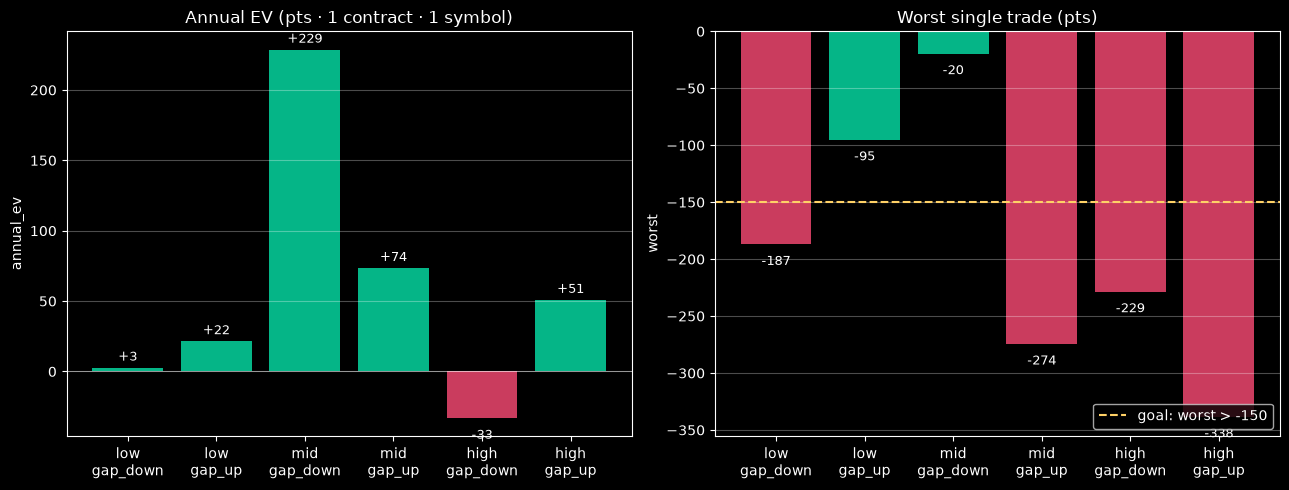

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
vd = stratify(df, ['vix_regime', 'direction'])
order = [('low','gap_down'),('low','gap_up'),
         ('mid','gap_down'),('mid','gap_up'),
         ('high','gap_down'),('high','gap_up')]
vd = vd.set_index(['vix_regime','direction']).reindex(order).reset_index()
labels = [f"{v}\n{d}" for v, d in zip(vd['vix_regime'], vd['direction'])]
colors_ev = ['#06d6a0' if e > 0 else '#ef476f' for e in vd['annual_ev']]
colors_w  = ['#06d6a0' if w > -150 else '#ef476f' for w in vd['worst']]

ax = axes[0]
ax.bar(labels, vd['annual_ev'], color=colors_ev, alpha=0.85)
ax.axhline(0, color='white', lw=0.6, alpha=0.5)
ax.set_title('Annual EV (pts · 1 contract · 1 symbol)')
ax.set_ylabel('annual_ev')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(vd['annual_ev']):
    ax.text(i, v + (5 if v >= 0 else -15), f'{v:+.0f}', ha='center', fontsize=9)

ax = axes[1]
ax.bar(labels, vd['worst'], color=colors_w, alpha=0.85)
ax.axhline(-150, color='#ffd166', lw=1.5, ls='--', label='goal: worst > -150')
ax.set_title('Worst single trade (pts)')
ax.set_ylabel('worst')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(vd['worst']):
    ax.text(i, v - 18, f'{v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('charts/p2_02_vix_direction_grid.png', dpi=150, bbox_inches='tight')
plt.show()


### EV vs worst-trade — every 3D cell as a bubble

X = worst trade (further right = better tail).
Y = annual EV (higher = more profitable).
Size = trades per year.
Color = direction.


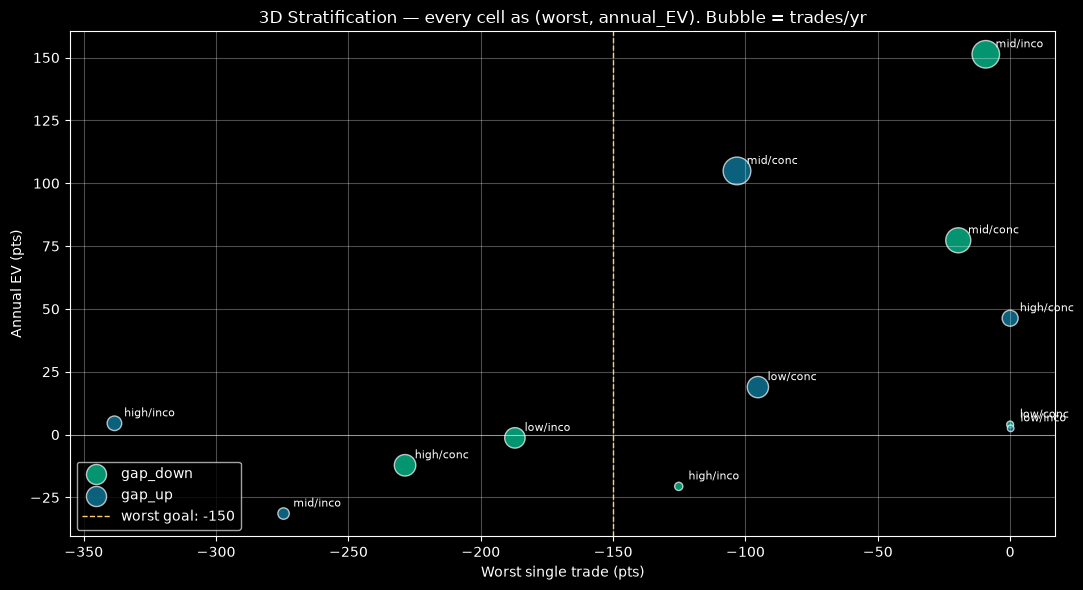

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
for direction, color in [('gap_down', '#06d6a0'), ('gap_up', '#118ab2')]:
    sub = strat3d[strat3d['direction'] == direction]
    ax.scatter(sub['worst'], sub['annual_ev'],
               s=sub['n_yr'] * 25, alpha=0.7, c=color, edgecolor='white',
               label=direction, linewidths=1)
    for _, row in sub.iterrows():
        ax.annotate(f"{row['vix_regime']}/{row['alignment'][:4]}",
                    (row['worst'], row['annual_ev']),
                    xytext=(7, 5), textcoords='offset points', fontsize=8)
ax.axhline(0, color='white', lw=0.6, alpha=0.5)
ax.axvline(-150, color='#ffd166', lw=1, ls='--', label='worst goal: -150')
ax.set_xlabel('Worst single trade (pts)')
ax.set_ylabel('Annual EV (pts)')
ax.set_title('3D Stratification — every cell as (worst, annual_EV). Bubble = trades/yr')
ax.legend(loc='lower left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/p2_03_stratify_bubbles.png', dpi=150, bbox_inches='tight')
plt.show()


## 7 · Candidate rules — what to actually trade

Cells that meet **EV > 0**, **worst > −150**, **n_yr ≥ 5**:


In [9]:
def find_candidates(df):
    results = []
    for grouping in (['vix_regime', 'direction'],
                     ['alignment',  'direction'],
                     ['vix_regime', 'alignment'],
                     ['vix_regime', 'alignment', 'direction']):
        s = stratify(df, grouping)
        ok = s[(s['ev_per_trade'] > 0) & (s['worst'] > -150) & (s['n_yr'] >= 5)].copy()
        if len(ok) > 0:
            ok['grouping'] = '×'.join(grouping)
            results.append(ok)
    return pd.concat(results, ignore_index=True) if results else pd.DataFrame()

cands = find_candidates(df)
print(cands.to_string(index=False))

# Save event table for downstream phase 2 work
os.makedirs('cache', exist_ok=True)
df.to_csv('cache/phase2_events_075.csv', index=False)
print(f'\nEvent table cached: cache/phase2_events_075.csv ({len(df)} rows)')


vix_regime direction   n  n_yr  ev_per_trade  annual_ev  win_%  p10  p25  worst  avg_credit                       grouping   alignment
       low    gap_up  72  10.3          2.09       21.5   94.4 0.04 0.53  -95.3        5.07           vix_regime×direction         NaN
       mid  gap_down 201  28.7          7.96      228.6   93.5 0.12 1.01  -19.6        8.64           vix_regime×direction         NaN
       NaN    gap_up 214  30.6          5.56      170.1   96.7 0.11 0.86 -103.2        7.79            alignment×direction  concurrent
       low       NaN  73  10.4          2.20       22.9   94.5 0.01 0.45  -95.3        5.14           vix_regime×alignment  concurrent
       mid       NaN 202  28.9          6.31      182.2   94.1 0.07 0.88 -103.2        8.10           vix_regime×alignment  concurrent
      high    gap_up  37   5.3          8.76       46.3  100.0 0.18 0.65    0.0        8.76 vix_regime×alignment×direction  concurrent
       low    gap_up  66   9.4          2.01       18.9

## 8 · Findings — Task 9

### Rule R1 — recommended primary
**0.75×ATR threshold · VIX 15–25 · gap_down only · NS·EOD exit**

| Metric | Value |
|---|---:|
| Events / yr | 28.7 |
| Avg credit  | 8.64 pts |
| EV / trade  | **+7.96 pts** |
| Annual EV   | **+228.6 pts** |
| Win rate    | 93.5% |
| Worst trade | **−19.6 pts** |

At ES tick value $50 → annual EV ≈ **$11 400** per contract per symbol,
worst single-day loss ≈ **−$980**. Across the four symbols (which all gap on the
same macro days), the combined position is roughly 4× this — though correlated.

### Rule R2 — purest cell, lower frequency
**0.75×ATR · VIX 15–25 · incongruent · gap_down only**

15.7 events/yr, EV +9.63, annual +151, worst **−9.2 pts**, win 96.4%.
This is the cleanest mean-reversion setup — overnight fear gap **against** a
bullish 30-day trend in mid-VIX conditions. Tail risk practically nil at the
1-contract scale.

### Cells to AVOID
| Cell | Why |
|---|---|
| high-VIX × concurrent × gap_down | EV −1.28, worst −338.4 — width inflates with VIX |
| mid-VIX × incongruent × gap_up   | EV −11.57, worst −274.5 — fear-bounce continuation |
| high-VIX × any × any             | width too wide; max loss per trade dominates |

### Why mid-VIX × gap_down is structurally bounded
Worst trade per cell ≈ (avg width − avg credit). Avg width = 0.5×ATR, so
filtering on VIX caps ATR which caps max loss. Gap-down direction adds the
"fear overshoots then reverts" asymmetry observed in the EDA. Together they
collapse the tail without much EV give-up.

### Cost of filtering vs unfiltered Phase 1 result
|  | Unfiltered NS·EOD | R1 (mid-VIX × gap_down) | Δ |
|---|---:|---:|---:|
| Trades/yr   | 88 | 28.7 | −67 % |
| Annual EV   | +347 | +228 | −34 % |
| Worst trade | −338 | **−19.6** | **+94 %** |

Cut frequency by 2/3 and EV by 1/3 — gain a 17× reduction in worst-trade size.
Risk-adjusted return is dramatically better.

### Open caveats
- No slippage / commissions modeled. Credit ≈ 8.64 pts; if real bid-ask is
  1–2 pts on these spreads, ~15–25 % of EV erodes immediately.
- 4 symbols gap together → R1 trades are 4-way correlated; treat as one
  macro signal with ~28 unique trading days/yr, not 4×28 independent trades.
- VIX is measured at prev close. Real-time decision uses the same.
- 7 years of data. The 2020 vol spike and 2022 inflation regime are present;
  a deeper drawdown regime (2008-style) is not.

### Phase 2 task list — updated
| # | Task | Status |
|---|---|---|
| 9  | VIX × alignment × direction stratification | **done — R1 / R2 identified** |
| 10 | Gap-size tier interaction (0.75–1.0, 1.0–1.5, 1.5+) within R1 | next |
| 11 | Exit-rule optimization within R1: PT sweep, time-based exits, soft stops | after 10 |
| 12 | Build `07_phase2_conditional.ipynb` (final Phase 2 presentation + paper-trade spec) | after 11 |
